In [1]:
import pickle

with open("outputs.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"]
y = data["y"]
xgb_preds = data["xgb_preds"]
feature_names = data["feature_names"]

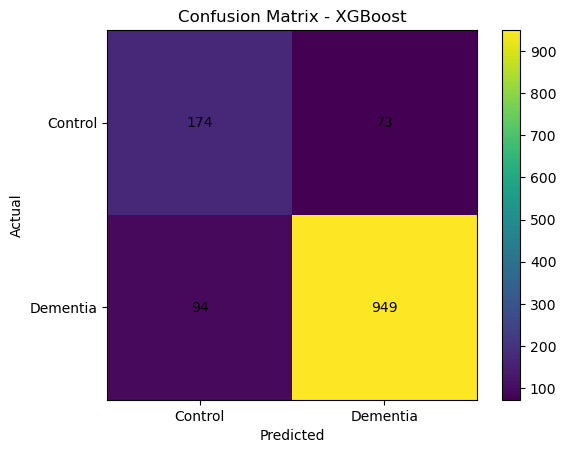

In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y, xgb_preds)

plt.imshow(cm)
plt.title("Confusion Matrix - XGBoost")
plt.colorbar()

plt.xticks([0,1], ["Control", "Dementia"])
plt.yticks([0,1], ["Control", "Dementia"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

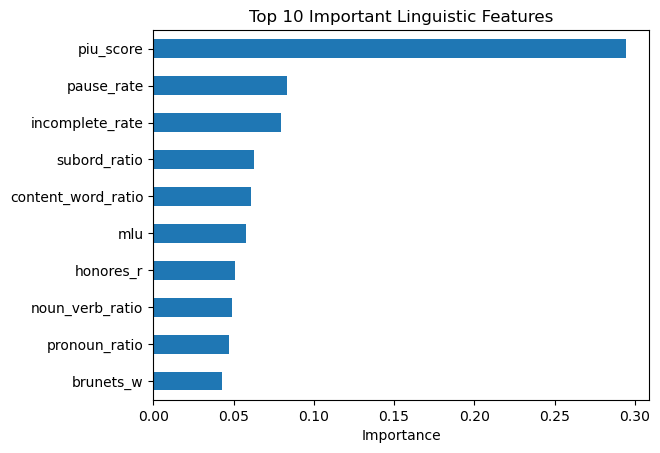

In [3]:
import pandas as pd

importances = data["xgb_model"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names)

feat_imp.sort_values().tail(10).plot(kind="barh")
plt.title("Top 10 Important Linguistic Features")
plt.xlabel("Importance")
plt.show()

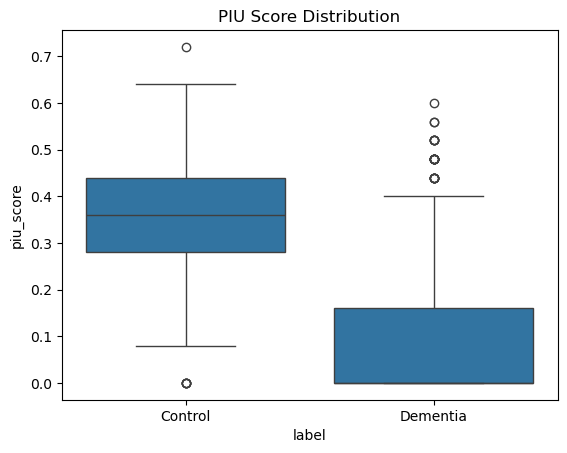

In [4]:
import seaborn as sns

df = X.copy()
df["label"] = y

sns.boxplot(x="label", y="piu_score", data=df)
plt.xticks([0,1], ["Control", "Dementia"])
plt.title("PIU Score Distribution")
plt.show()

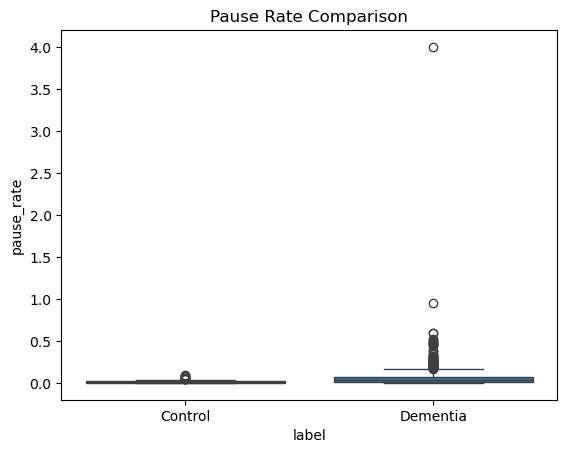

In [5]:
sns.boxplot(x="label", y="pause_rate", data=df)
plt.xticks([0,1], ["Control", "Dementia"])
plt.title("Pause Rate Comparison")
plt.show()

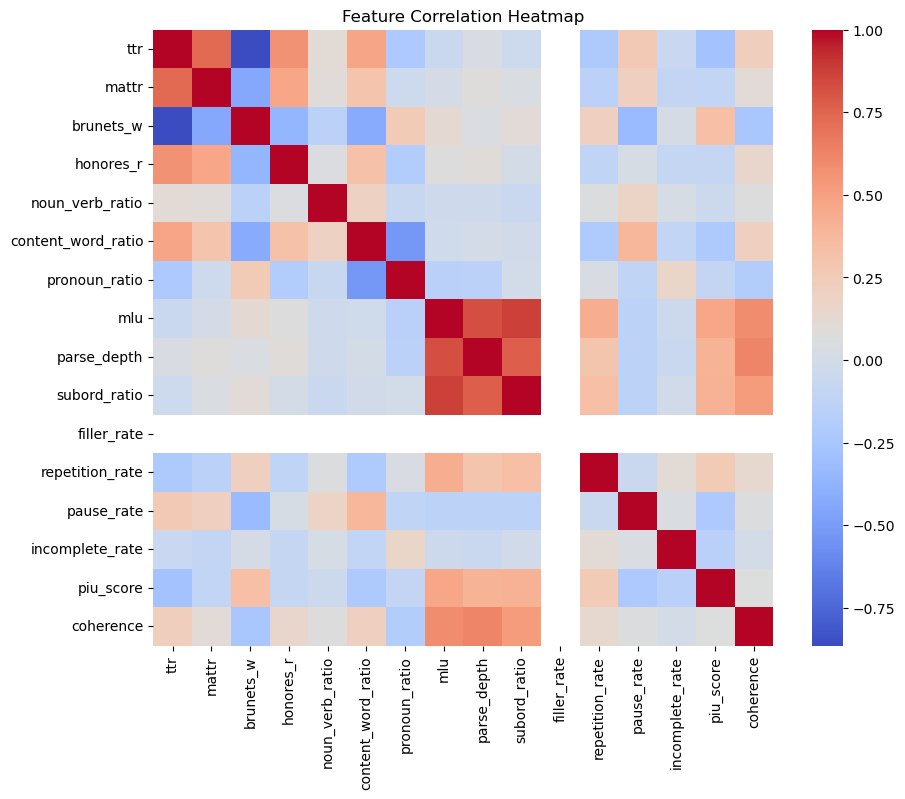

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()